<a href="https://colab.research.google.com/github/Yaaxek/TelecomX-Parte2-Churn/blob/main/TelecomX_Parte2_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Telecom X: Predicción de Cancelación (Churn)**

##**🎯 Misión**

Tu nueva misión es desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.

La empresa quiere anticiparse al problema de la cancelación, y te corresponde a i construir un pipeline robusto para esta etapa inicial de modelado.

##**🛠️ Preparación de los Datos**

###**Extracción del Archivo Tratado**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
datos=pd.read_csv('/content/drive/MyDrive/TelecomX_LATAM/datos_tratados.csv')
datos

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias,Cantidad_Servicios
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.186667,4
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.996667,3
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.463333,2
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.266667,5
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.796667,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,9987-LUTYD,0,Female,0,0,0,13,1,0,DSL,1,0,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.838333,3
7039,9992-RRAMN,1,Male,0,1,0,22,1,1,Fiber optic,0,0,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.836667,3
7040,9992-UJOEL,0,Male,0,0,0,2,1,0,DSL,0,1,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.676667,2
7041,9993-LHIEB,0,Male,0,1,1,67,1,0,DSL,1,0,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.261667,5


In [5]:
datos.shape

(7043, 23)

###**Eliminación de Columnas Irrelevantes**

In [6]:
datos.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Cuentas_Diarias', 'Cantidad_Servicios'],
      dtype='object')

In [7]:
datos.drop(columns='customerID', inplace=True)

In [8]:
datos.sample(5)

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias,Cantidad_Servicios
3245,0,Male,0,1,1,55,1,0,0,0,0,0,0,0,0,One year,0,Mailed check,19.50,1026.35,0.650000,1
6073,0,Male,0,1,1,38,1,0,DSL,1,1,1,1,1,0,One year,0,Electronic check,74.05,2802.30,2.468333,6
2892,0,Male,1,0,0,71,1,1,Fiber optic,0,1,0,1,1,1,Two year,1,Electronic check,106.80,7623.20,3.560000,6
1327,0,Male,0,1,0,7,0,0,DSL,1,1,0,0,0,0,Month-to-month,0,Mailed check,34.20,256.60,1.140000,2
5166,0,Male,0,1,1,62,1,0,0,0,0,0,0,0,0,Two year,0,Bank transfer (automatic),20.45,1297.35,0.681667,1


In [9]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Churn               7043 non-null   int64  
 1   gender              7043 non-null   object 
 2   SeniorCitizen       7043 non-null   int64  
 3   Partner             7043 non-null   int64  
 4   Dependents          7043 non-null   int64  
 5   tenure              7043 non-null   int64  
 6   PhoneService        7043 non-null   int64  
 7   MultipleLines       7043 non-null   int64  
 8   InternetService     7043 non-null   object 
 9   OnlineSecurity      7043 non-null   int64  
 10  OnlineBackup        7043 non-null   int64  
 11  DeviceProtection    7043 non-null   int64  
 12  TechSupport         7043 non-null   int64  
 13  StreamingTV         7043 non-null   int64  
 14  StreamingMovies     7043 non-null   int64  
 15  Contract            7043 non-null   object 
 16  Paperl

###**Encoding**

In [10]:
from sklearn.preprocessing import OneHotEncoder

In [11]:
df_model=datos.copy()
categoricas=['gender','InternetService','Contract','PaymentMethod']

encoder=OneHotEncoder(drop='if_binary',sparse_output=False)
encoded=encoder.fit_transform(df_model[categoricas])
encoded_cols=encoder.get_feature_names_out(categoricas)
df_encoded=pd.DataFrame(encoded,columns=encoded_cols,index=df_model.index)
df_encoded=df_encoded.astype(int)
datos=pd.concat([df_model.drop(columns=categoricas),df_encoded],axis=1)


In [12]:
datos.sample(5)

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias,Cantidad_Servicios,gender_Male,InternetService_0,InternetService_DSL,InternetService_Fiber optic,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
667,0,0,1,0,26,1,1,1,1,1,1,1,1,1,90.10,2312.55,3.003333,8,0,0,1,0,0,1,0,0,1,0,0
5167,0,0,0,0,55,1,0,0,0,0,0,0,0,0,45.05,2462.60,1.501667,1,0,0,1,0,0,1,0,1,0,0,0
1420,0,0,1,1,72,1,1,0,1,0,1,1,1,1,78.95,5730.15,2.631667,6,0,0,1,0,0,0,1,0,0,1,0
3127,1,0,1,0,52,1,1,0,1,1,0,1,1,1,105.05,5624.85,3.501667,6,0,0,0,1,1,0,0,0,0,1,0
6756,0,0,1,0,69,1,1,0,1,0,1,1,0,1,92.45,6460.55,3.081667,5,1,0,0,1,0,0,1,0,0,0,1


In [13]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Churn                                    7043 non-null   int64  
 1   SeniorCitizen                            7043 non-null   int64  
 2   Partner                                  7043 non-null   int64  
 3   Dependents                               7043 non-null   int64  
 4   tenure                                   7043 non-null   int64  
 5   PhoneService                             7043 non-null   int64  
 6   MultipleLines                            7043 non-null   int64  
 7   OnlineSecurity                           7043 non-null   int64  
 8   OnlineBackup                             7043 non-null   int64  
 9   DeviceProtection                         7043 non-null   int64  
 10  TechSupport                              7043 no

###**Verificación de la Proporción de Cancelación (Churn)**

In [14]:
datos['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [15]:
datos.Churn.value_counts(normalize=True)*100

,proportion
Churn,
0,73.463013
1,26.536987


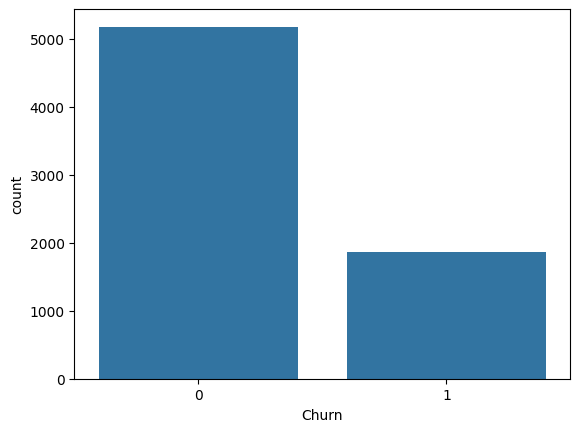

In [16]:
import seaborn as sns
sns.countplot(data=datos,x='Churn');

####**NOTA:**
La proporción de clientes activos es aproximadamente 73.46%, mientras que el 26.54% cancelaron el servicio. Esto indica la presencia de un desbalance moderado entre las clases. Aunque no es extremo, puede influir en el desempeño de los modelos predictivos, ya que estos podrían favorecer la clase mayoritaria. Por ello, será importante considerar métricas adecuadas y, de ser necesario, aplicar técnicas para manejar el desbalance.

###**Normalización**

In [17]:
datos[['tenure','Charges.Monthly','Charges.Total','Cuentas_Diarias']].describe()

,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.158723
std,24.559481,30.090047,2266.794470,1.003002
min,0.000000,18.250000,0.000000,0.608333
25%,9.000000,35.500000,398.550000,1.183333
50%,29.000000,70.350000,1394.550000,2.345000
75%,55.000000,89.850000,3786.600000,2.995000
max,72.000000,118.750000,8684.800000,3.958333


In [18]:
from sklearn.preprocessing import StandardScaler
df_scaled=datos.copy()
numericas=['tenure','Charges.Monthly','Charges.Total','Cuentas_Diarias']
scaler=StandardScaler()
df_scaled[numericas]=scaler.fit_transform(df_scaled[numericas])
df_scaled.sample(5)

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias,Cantidad_Servicios,gender_Male,InternetService_0,InternetService_DSL,InternetService_Fiber optic,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1561,0,0,1,0,1.613701,1,1,1,1,1,0,1,1,1,1.528465,2.414138,1.528465,7,0,0,0,1,0,0,1,0,0,1,0
3928,0,0,0,0,0.595692,1,0,0,0,0,0,0,0,0,-1.482712,-0.544214,-1.482712,1,0,1,0,0,0,0,1,0,0,0,1
4464,0,0,1,0,1.613701,1,1,1,1,1,0,1,1,1,1.491905,2.470852,1.491905,7,1,0,0,1,0,0,1,0,0,1,0
2110,1,0,0,0,-1.277445,1,0,0,0,0,0,1,1,1,0.835495,-0.966117,0.835495,3,1,0,0,1,1,0,0,0,0,1,0
2502,0,0,1,1,1.165777,1,1,0,0,0,0,0,0,1,-1.348106,-0.368182,-1.348106,2,0,1,0,0,0,0,1,0,0,0,1


Media original: ternure, Charges.Monthly, Charges.Total y Cuentas_Diarias

In [19]:
scaler.mean_

array([3.23711487e+01, 6.47616925e+01, 2.27973430e+03, 2.15872308e+00])

In [20]:
scaler.scale_

array([2.45577374e+01, 3.00879109e+01, 2.26663354e+03, 1.00293036e+00])

##**🎯 Correlación y Selección de Variables**

###**Análisis de Correlación**

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

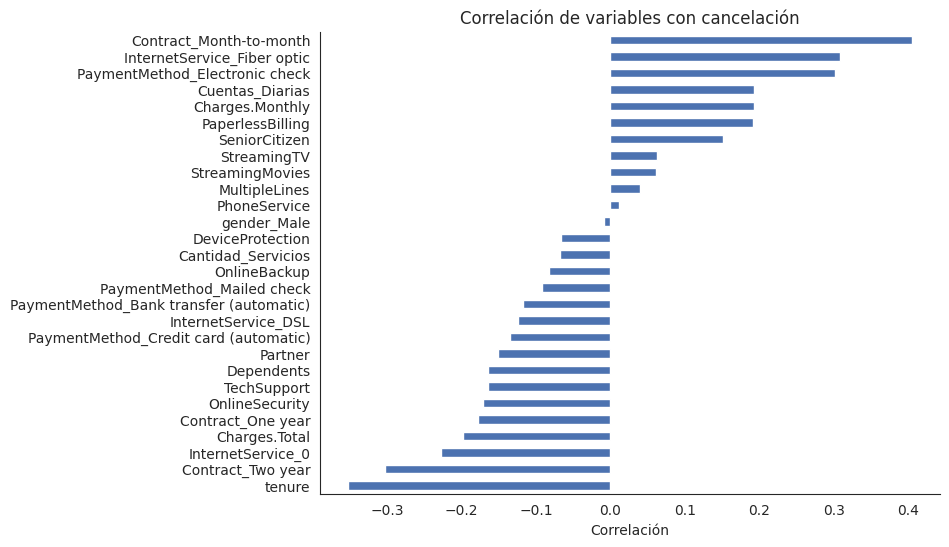

In [22]:
corr_churn = df_scaled.corr()["Churn"].drop("Churn").sort_values()

sns.set_style("white")

plt.figure(figsize=(8,6))
ax = corr_churn.plot(kind="barh", color="#4C72B0")

sns.despine(top=True, right=True)
plt.xlabel("Correlación")
plt.ylabel("")
plt.title("Correlación de variables con cancelación")
plt.show()

####**NOTA:**
Para facilitar la interpretación, se analizó la correlación de cada variable con la cancelación. Se observa que variables como tenure, Contract y Charges.Monthly presentan mayor relación con churn, lo que sugiere que pueden ser relevantes para el modelo predictivo.

###**Análisis Dirigido**

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

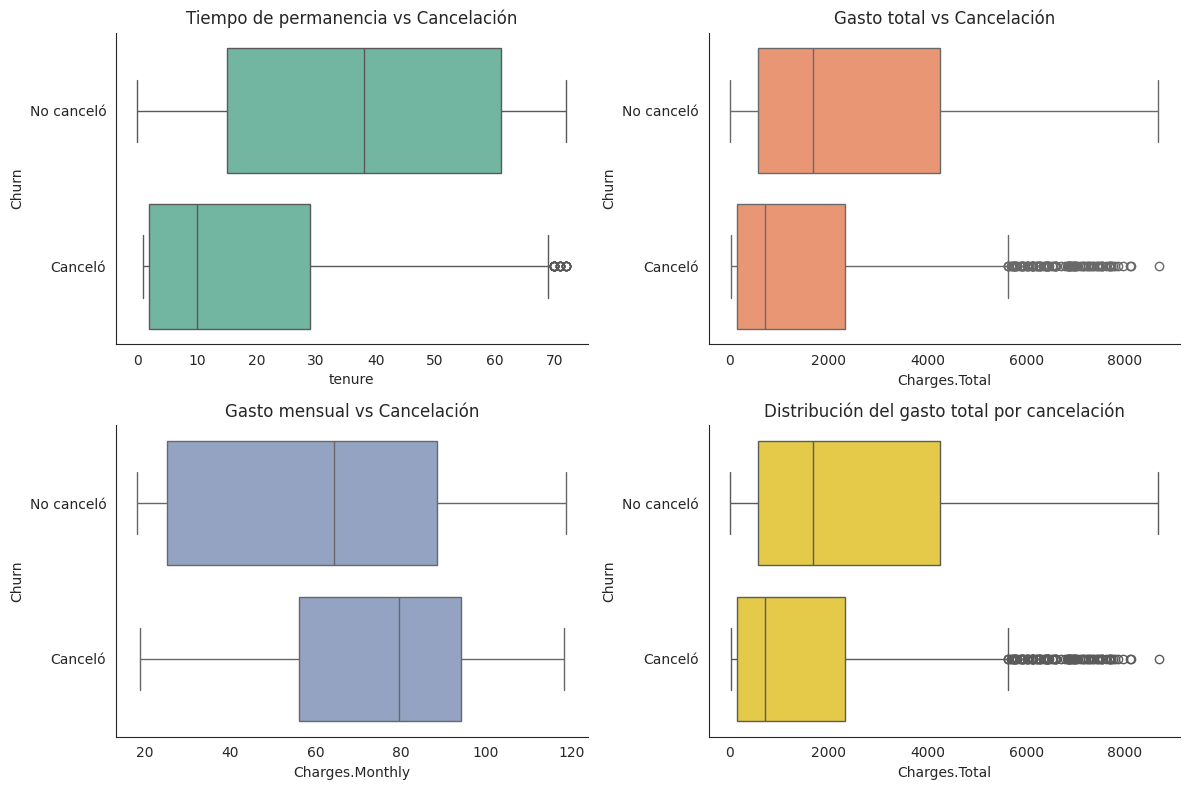

In [33]:
sns.set_style("white")

temp = datos[["Churn", "tenure", "Charges.Total", "Charges.Monthly"]].copy()
temp["Churn"] = temp["Churn"].map({0: "No canceló", 1: "Canceló"})

fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.boxplot(data=temp, x="tenure", y="Churn", ax=axes[0,0], color="#66c2a5")
axes[0,0].set_title("Tiempo de permanencia vs Cancelación")

sns.boxplot(data=temp, x="Charges.Total", y="Churn", ax=axes[0,1], color="#fc8d62")
axes[0,1].set_title("Gasto total vs Cancelación")

sns.boxplot(data=temp, x="Charges.Monthly", y="Churn", ax=axes[1,0], color="#8da0cb")
axes[1,0].set_title("Gasto mensual vs Cancelación")

sns.boxplot(data=temp, x="Charges.Total", y="Churn", ax=axes[1,1], color="#ffd92f")
axes[1,1].set_title("Distribución del gasto total por cancelación")

sns.despine()
plt.tight_layout()
plt.show()

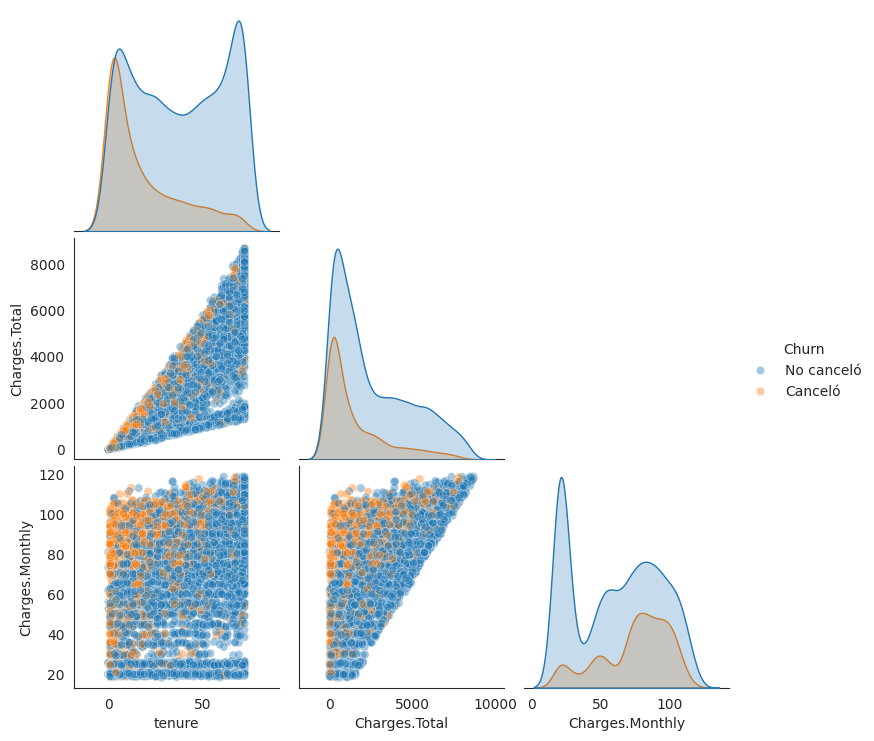

In [34]:
sns.set_style("white")
pair_data = datos[["tenure", "Charges.Total", "Charges.Monthly", "Churn"]].copy()

pair_data["Churn"] = pair_data["Churn"].map({0: "No canceló", 1: "Canceló"})
sns.pairplot(
    pair_data,
    hue="Churn",
    corner=True,
    diag_kind="kde",
    plot_kws={"alpha":0.4}
)

plt.show()

####**NOTA:**
Los gráficos muestran patrones claros en relación con la cancelación. Se observa que los clientes que cancelan presentan menor tiempo de permanencia y menor gasto total, lo que sugiere que los clientes más nuevos tienen mayor probabilidad de abandonar el servicio. Asimismo, se identifica que los clientes que cancelan tienden a tener un gasto mensual ligeramente mayor, lo que podría indicar sensibilidad al precio. Estos resultados coinciden con la matriz de correlación y sugieren que estas variables son relevantes para el modelo predictivo.

##**🤖 Modelado Predictivo**

###**Separación de Datos**

In [36]:
from sklearn.model_selection import train_test_split
X=df_scaled.drop(columns='Churn')
y=df_scaled['Churn']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


####**NOTA:**
El conjunto de datos se dividió en entrenamiento y prueba utilizando una proporción 80/20. Se empleó stratify para mantener la proporción de la variable objetivo en ambos conjuntos. Esta división permite entrenar el modelo y evaluar su desempeño en datos no vistos.

##**Creación de Modelos**